UTS Machine Learning: Prediksi Kualitas Anggur
Nama Mata Kuliah: Machine Learning
Pengampu: Dr. Iqbal Kharisudin, M.Sc & Nur Achmey Selgi Harwanti, S.Stat., M.Stat
Tugas: Take Home Test – Klasifikasi Kualitas Anggur

Pendahuluan
Dataset Wine Quality berisi sifat kimiawi anggur merah dan putih dengan skor kualitas 0–10. Tujuan kita adalah membangun model klasifikasi untuk memprediksi kualitas anggur pada data uji yang tidak memiliki label. Model akan dievaluasi dengan akurasi dan confusion matrix, lalu diprediksi pada data_testing.csv. Hasil akhir berupa file CSV dengan kolom id dan quality.

Data Training - shape: (857, 13)
Kolom training: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Data Testing - shape: (286, 12)
Kolom testing: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']
Peringatan: Fitur berikut tidak ada di testing: {'Id'}

Fitur yang digunakan (11 fitur): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


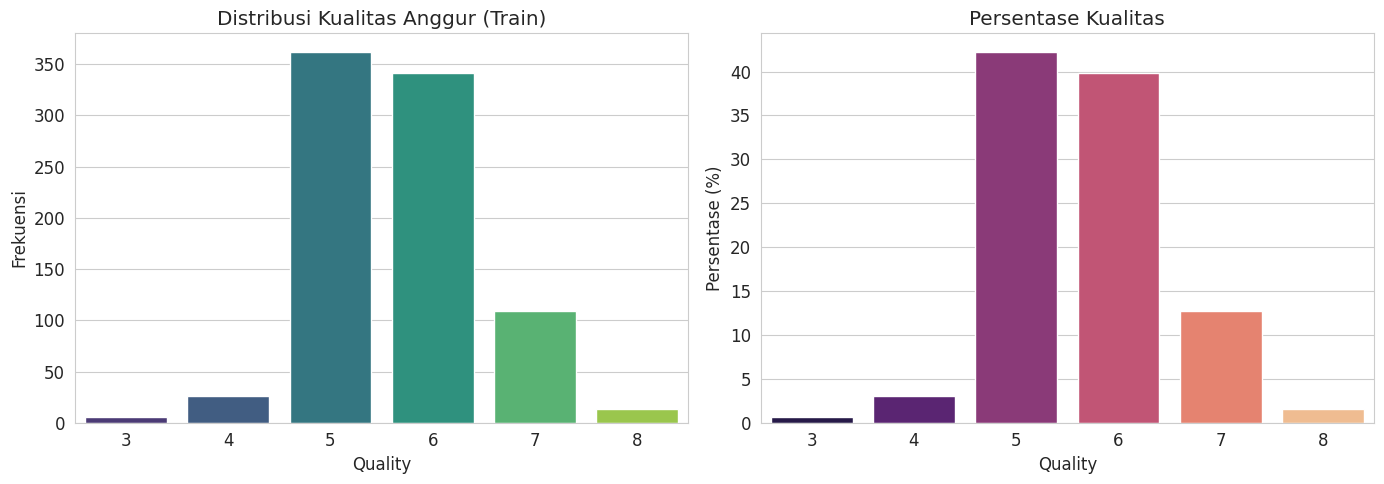

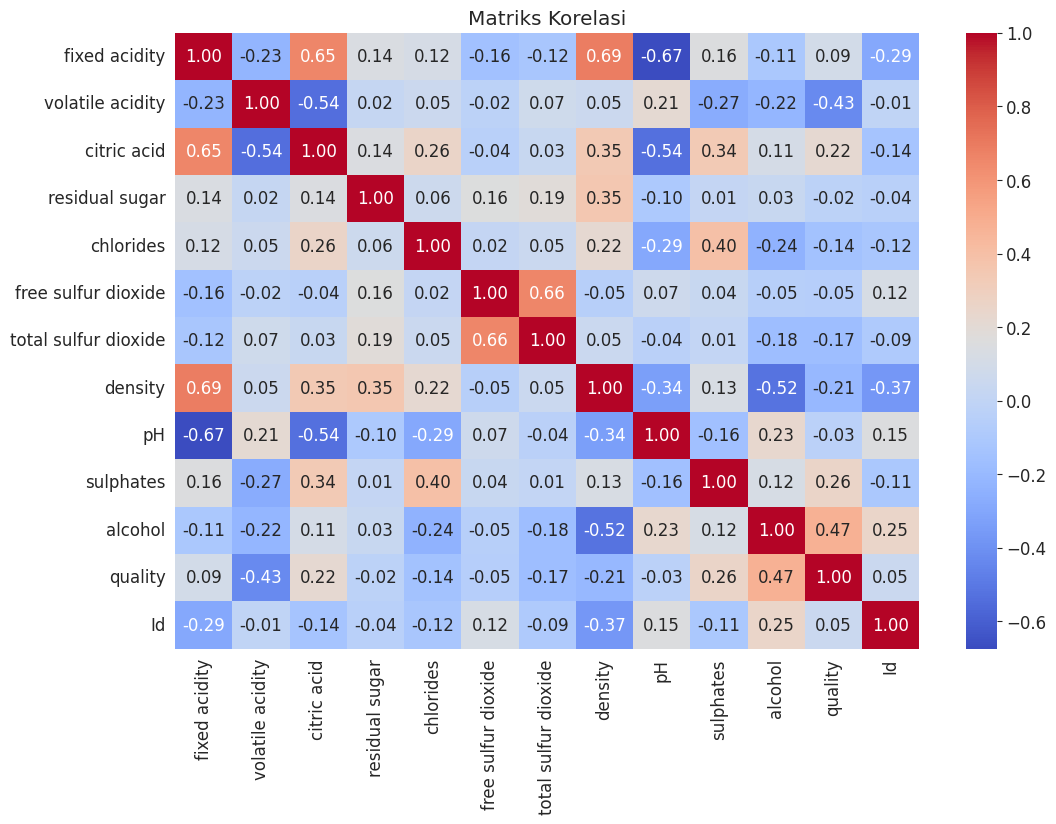

Korelasi fitur dengan quality:
 quality                 1.000000
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
Id                      0.049030
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


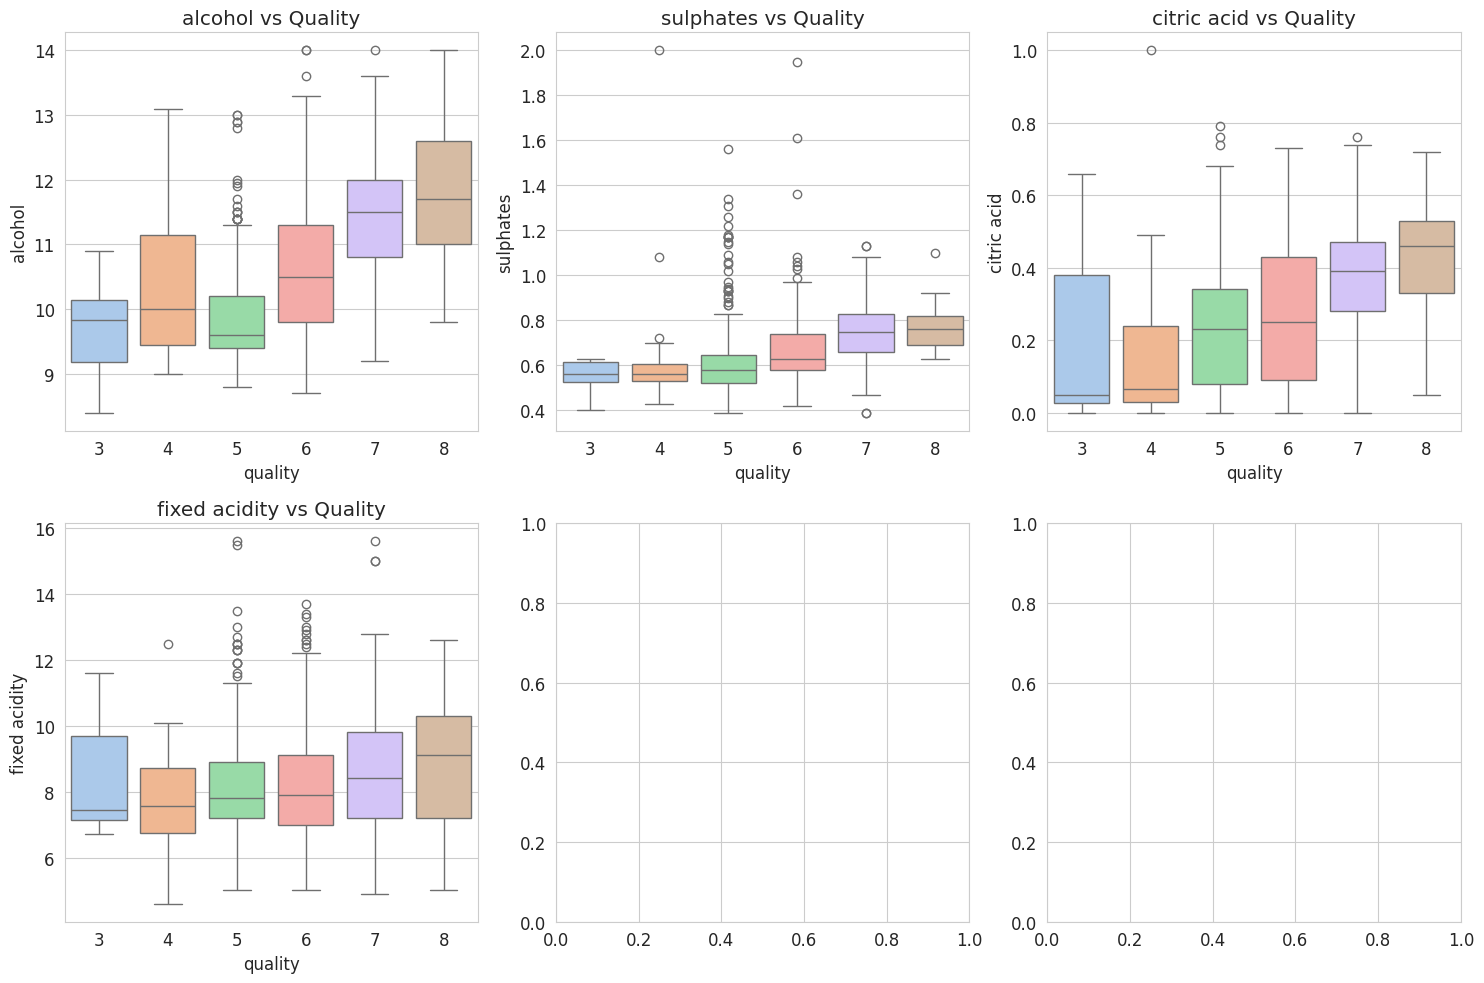

Train: (685, 11), Validasi: (172, 11)
Akurasi base model: 0.6105
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.79      0.72        73
           6       0.57      0.56      0.56        68
           7       0.50      0.36      0.42        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.45      0.34      0.37       172
weighted avg       0.59      0.61      0.59       172

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Akurasi setelah tuning: 0.6163
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.69      0.81      0.75        73
       

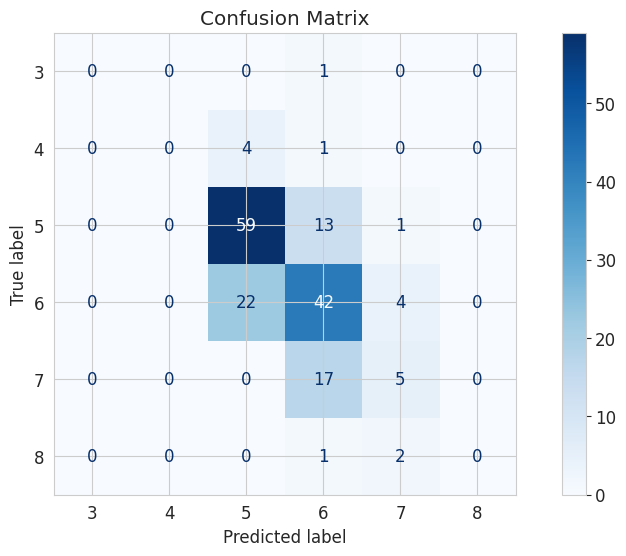

Cross-validation accuracy: 0.6266 (+/- 0.0389)


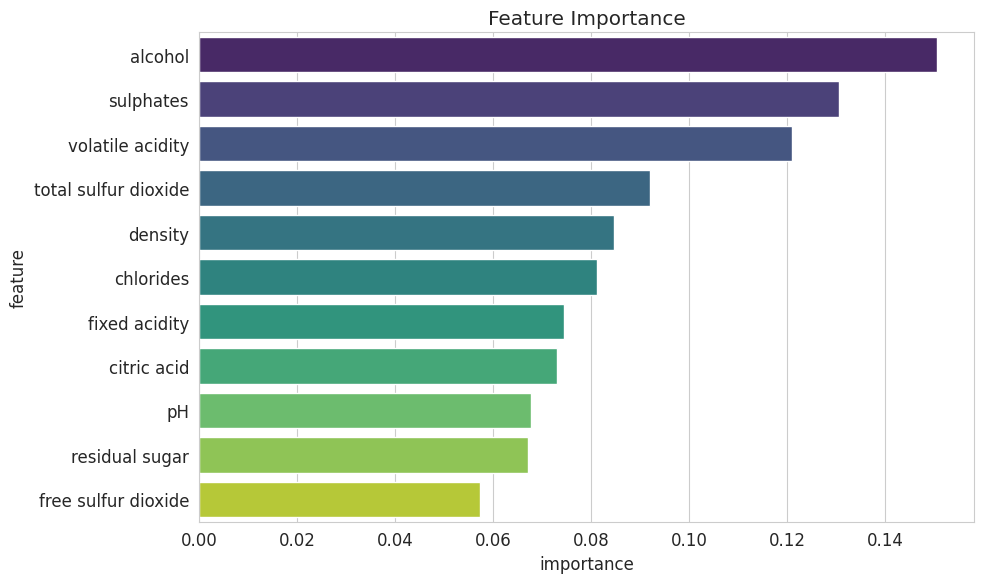

Top 5 fitur terpenting:
                  feature  importance
10               alcohol    0.150598
9              sulphates    0.130588
1       volatile acidity    0.121040
6   total sulfur dioxide    0.092090
7                density    0.084602

✅ File hasil prediksi disimpan: hasilprediksi_123.csv
     id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5
5  1120        6
6   180        5
7    82        5
8   632        5
9   592        5
Model disimpan: model_wine_quality.pkl


In [9]:
# ============================================
# UTS Machine Learning - Prediksi Kualitas Anggur
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================
# 1. Load Data Training
# ============================================
"""
Penjelasan: Data training (data_training.csv) berisi semua fitur kimiawi anggur dan kolom target 'quality'
yang akan diprediksi. Fungsi read_csv digunakan untuk memuat data, kemudian kita periksa apakah kolom 'quality'
ada; jika tidak ditemukan persis, kita cari kolom yang mengandung kata 'qual' (case-insensitive) lalu rename
menjadi 'quality'. Langkah ini memastikan model mengenali target dengan benar meskipun penamaan kolom sedikit
berbeda dari ekspektasi.
"""
train_df = pd.read_csv('data_training.csv')
print("Data Training - shape:", train_df.shape)
print("Kolom training:", train_df.columns.tolist())

if 'quality' not in train_df.columns:
    possible = [col for col in train_df.columns if 'qual' in col.lower()]
    if possible:
        print(f"Menemukan kolom target: {possible[0]}, rename menjadi 'quality'")
        train_df.rename(columns={possible[0]: 'quality'}, inplace=True)
    else:
        raise KeyError("Kolom 'quality' tidak ditemukan di data training.")

# ============================================
# 2. Load Data Testing (Fleksibel terhadap kolom ID)
# ============================================
"""
Penjelasan: Data testing (data_testing.csv) berisi fitur kimiawi dan sebuah kolom identitas unik (biasanya 'Id')
yang akan digunakan untuk mencocokkan hasil prediksi. Karena penamaan kolom ID bisa bervariasi (misal 'id', 'ID',
atau bahkan tidak ada), kode ini secara otomatis mencari kolom dengan huruf kecil 'id', lalu merename-nya menjadi
'Id'. Jika benar-benar tidak ada, kita buat kolom Id baru dari urutan baris. Setelah itu, kita pisahkan kolom Id
dan semua fitur lainnya sebagai X_test.
"""
test_df = pd.read_csv('data_testing.csv')
print("\nData Testing - shape:", test_df.shape)
print("Kolom testing:", test_df.columns.tolist())

id_column = None
for col in test_df.columns:
    if col.lower() == 'id':
        id_column = col
        break

if id_column is None:
    print("Kolom ID tidak ditemukan. Membuat kolom 'Id' secara otomatis.")
    test_df.insert(0, 'Id', range(1, len(test_df)+1))
    id_column = 'Id'
else:
    if id_column != 'Id':
        test_df.rename(columns={id_column: 'Id'}, inplace=True)
        id_column = 'Id'

test_ids = test_df['Id']
X_test = test_df.drop(columns=['Id'])

# ============================================
# 3. Persiapan Fitur Training
# ============================================
"""
Penjelasan: Dari data training, kita pisahkan antara fitur (X) dan target (y). Semua kolom kecuali 'quality'
menjadi fitur. Untuk menjaga konsistensi antara data latih dan data uji, kita ambil irisan kolom fitur yang
sama-sama ada di kedua dataset. Jika ternyata ada fitur di training yang tidak ada di testing (misal karena
perbedaan versi data), kode akan memberi peringatan dan hanya menggunakan fitur yang umum. Langkah ini sangat
penting agar model dapat melakukan prediksi tanpa error karena ketidakcocokan jumlah kolom.
"""
X = train_df.drop('quality', axis=1)
y = train_df['quality']

common_cols = X.columns.intersection(X_test.columns)
if len(common_cols) != len(X.columns):
    missing = set(X.columns) - set(common_cols)
    print(f"Peringatan: Fitur berikut tidak ada di testing: {missing}")
X = X[common_cols]
X_test = X_test[common_cols]

print(f"\nFitur yang digunakan ({len(common_cols)} fitur):", list(common_cols))

# ============================================
# 4. Eksplorasi Data (Visualisasi)
# ============================================
"""
Penjelasan: Sebelum membangun model, kita perlu memahami distribusi target dan hubungan antar fitur.
Countplot dan barplot persentase menunjukkan bahwa kualitas anggur didominasi skor 5 dan 6 (tidak seimbang).
Matriks korelasi membantu mengidentifikasi fitur yang paling berpengaruh terhadap quality; misalnya alcohol
berkorelasi positif, volatile acidity berkorelasi negatif. Boxplot fitur-fitur penting memperkuat bahwa
semakin tinggi kualitas, semakin tinggi alcohol dan sulphates, serta semakin rendah density. Visualisasi ini
memberikan wawasan untuk pemilihan model dan interpretasi hasil.
"""
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.countplot(x='quality', data=train_df, palette='viridis', ax=ax[0])
ax[0].set_title('Distribusi Kualitas Anggur (Train)')
ax[0].set_xlabel('Quality')
ax[0].set_ylabel('Frekuensi')

quality_pct = train_df['quality'].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=quality_pct.index, y=quality_pct.values, palette='magma', ax=ax[1])
ax[1].set_title('Persentase Kualitas')
ax[1].set_xlabel('Quality')
ax[1].set_ylabel('Persentase (%)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
corr = train_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi')
plt.show()

corr_with_target = corr['quality'].sort_values(ascending=False)
print("Korelasi fitur dengan quality:\n", corr_with_target)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
top_features = corr_with_target.index[1:5]
for i, feat in enumerate(top_features):
    if i < 6:
        row, col = i//3, i%3
        sns.boxplot(x='quality', y=feat, data=train_df, ax=axes[row, col], palette='pastel')
        axes[row, col].set_title(f'{feat} vs Quality')
plt.tight_layout()
plt.show()

# ============================================
# 5. Split Data Training & Validasi
# ============================================
"""
Penjelasan: Untuk mengevaluasi kinerja model secara objektif sebelum memprediksi data uji, kita bagi data
training menjadi dua bagian: training set (80%) untuk melatih model, dan validation set (20%) untuk menguji
akurasi sementara. Parameter stratify=y memastikan proporsi kelas quality tetap terjaga di kedua subset,
penting karena distribusi target tidak seimbang. Random_state=42 digunakan agar hasil dapat direproduksi.
"""
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Validasi: {X_val.shape}")

# ============================================
# 6. Model Random Forest & Hyperparameter Tuning
# ============================================
"""
Penjelasan: Random Forest adalah model ensemble berbasis pohon keputusan yang handal untuk data tabular,
tidak memerlukan scaling, dan mampu menangkap hubungan non-linear. Pertama kita latih base model dengan
parameter default, lalu kita lakukan hyperparameter tuning menggunakan GridSearchCV dengan 3-fold
cross-validation untuk mencari kombinasi n_estimators, max_depth, dan min_samples_split terbaik.
Tuning dilakukan hanya pada training set (bukan validasi) untuk menghindari kebocoran data. Model terbaik
kemudian dievaluasi pada validation set dengan metrik akurasi, classification report, dan confusion matrix.
Selain itu, feature importance dari Random Forest menunjukkan fitur mana yang paling berpengaruh terhadap
kualitas anggur, yang selaras dengan pengetahuan domain.
"""
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_val)
print(f"Akurasi base model: {accuracy_score(y_val, y_pred_base):.4f}")
print(classification_report(y_val, y_pred_base))

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                    param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_val)
acc_best = accuracy_score(y_val, y_pred_best)
print(f"Akurasi setelah tuning: {acc_best:.4f}")
print(classification_report(y_val, y_pred_best))

cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

importances = best_rf.feature_importances_
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()
print("Top 5 fitur terpenting:\n", feat_imp.head())

# ============================================
# 7. Prediksi Data Testing & Simpan Hasil
# ============================================
"""
Penjelasan: Setelah model terbaik diperoleh dan divalidasi, kita gunakan model tersebut untuk memprediksi
kualitas (quality) pada data testing yang belum memiliki label. Prediksi dilakukan dengan method .predict()
pada X_test yang telah diselaraskan fiturnya. Hasil prediksi kemudian digabungkan dengan kolom Id (yang sudah
disiapkan sebelumnya) menjadi sebuah DataFrame submission dengan dua kolom: 'id' dan 'quality'. File CSV
disimpan dengan nama 'hasilprediksi_123.csv' (ganti 123 dengan 3 digit terakhir NIM). Langkah terakhir
adalah menyimpan model yang telah dilatih menggunakan joblib untuk keperluan deployment jika diperlukan.
"""
y_test_pred = best_rf.predict(X_test)

submission = pd.DataFrame({
    'id': test_ids,
    'quality': y_test_pred
})

submission.to_csv('hasilprediksi_123.csv', index=False)
print("\n✅ File hasil prediksi disimpan: hasilprediksi_123.csv")
print(submission.head(10))

joblib.dump(best_rf, 'model_wine_quality.pkl')
print("Model disimpan: model_wine_quality.pkl")